# Análise de Block Influence (BI) no AnyGraph: Avaliação Multi-Dataset e Comparação de Métricas

Este notebook implementa e executa a análise completa de **Block Influence (BI)** nas camadas dos Experts do modelo **AnyGraph**, permitindo selecionar ou executar todos os datasets desejados:
- **`cora`**: Grafo de citações acadêmicas (25.191 nós).
- **`pubmed`**: Grafo biomédico (19.720 nós).
- **`synthetic`** (ou **`random`**): Embeddings gaussianos simulados $\mathcal{N}(0, 1)$.

### Métricas Calculadas:
1. **Cosine Distance (1 - Cosseno):** $BI_{\text{cos}} = 1 - \cos(\theta)$ $\rightarrow$ Salvo em `Block_Influence_results/cosseno/`
2. **Angular Distance (arccos/pi):** $BI_{\text{ang}} = \frac{\theta}{\pi}$ $\rightarrow$ Salvo em `Block_Influence_results/angular/`
3. **Comparação Direta (Angular vs Cosseno):** $\rightarrow$ Salvo em `Block_Influence_results/comparacao_angular_x_cosseno/`

In [8]:
import os
import sys
import torch as t
import torch.nn.functional as F
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# ==============================================================================
# CONFIGURAÇÃO: Escolha quais datasets executar
# Opções: 'cora', 'pubmed', 'synthetic' (ou 'random')
# Para executar todos, use: ['cora', 'pubmed', 'synthetic']
# ==============================================================================
DATASETS_TO_RUN = ["cora", "pubmed", "synthetic"]
NUM_SAMPLES = 1500  # Quantidade de amostras/nós por dataset
RANDOM_SEED = 42

# Identifica o diretorio OpenGraph de forma portavel
cwd = os.getcwd()
if os.path.basename(cwd) == "OpenGraph":
    PROJECT_ROOT = cwd
elif os.path.exists(os.path.join(cwd, "OpenGraph")):
    PROJECT_ROOT = os.path.join(cwd, "OpenGraph")
else:
    PROJECT_ROOT = os.path.abspath(".")

os.chdir(PROJECT_ROOT)
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
sys.argv = ["analysis"]

# Diretorios para salvar resultados organizados por metrica
BASE_DIR = os.path.abspath("..")
DIR_COS = os.path.join(BASE_DIR, "Block_Influence_results", "cosseno")
DIR_ANG = os.path.join(BASE_DIR, "Block_Influence_results", "angular")
DIR_COMP_METRICS = os.path.join(BASE_DIR, "Block_Influence_results", "comparacao_angular_x_cosseno")

ALL_COS_DIRS = [DIR_COS]
ALL_ANG_DIRS = [DIR_ANG]
ALL_COMP_DIRS = [DIR_COMP_METRICS]

for d in ALL_COS_DIRS + ALL_ANG_DIRS + ALL_COMP_DIRS:
    os.makedirs(d, exist_ok=True)

print(f"Datasets selecionados para execução: {DATASETS_TO_RUN}")
print(f"Número de amostras por dataset: {NUM_SAMPLES}")
print(f"Diretório Cosseno: {DIR_COS}")
print(f"Diretório Angular: {DIR_ANG}")
print(f"Diretório Comparação Métricas: {DIR_COMP_METRICS}")

Datasets selecionados para execução: ['cora', 'pubmed', 'synthetic']
Número de amostras por dataset: 1500
Diretório Cosseno: c:\Mestrado\Graph_Pruning\Block_Influence_results\cosseno
Diretório Angular: c:\Mestrado\Graph_Pruning\Block_Influence_results\angular
Diretório Comparação Métricas: c:\Mestrado\Graph_Pruning\Block_Influence_results\comparacao_angular_x_cosseno


In [9]:
import node_classification.Utils.TimeLogger as logger
from node_classification.Utils.TimeLogger import log

from node_classification.data_handler import *
from node_classification.model import *
from node_classification.main import *

## 1. Funções de Carregamento de Dados, Cálculo de Block Influence e Visualização

In [11]:
def load_model_from_checkpoint(checkpoint_path):
    """
    Carrega o modelo a partir do checkpoint .mod na CPU de forma rapida e estavel.
    """
    args.devices = ["cpu", "cpu"]

    checkpoint = t.load(
        f"Models/{checkpoint_path}.mod",
        map_location=t.device("cpu"),
        weights_only=False
    )

    model = checkpoint["model"]
    model.eval()

    return model

def get_opengraph_embeddings(exp, handler):

    model = exp.model
    model.eval()

    adj = handler.torch_adj
    initial_projector = handler.initial_projector

    if args.cache_adj == 0:
        adj = adj.to(args.devices[0])

    if args.cache_proj == 0:
        initial_projector = initial_projector.to(args.devices[0])

    with t.no_grad():
        embeds = initial_projector()

        topo_embeds = model.topoEncoder(
            adj,
            embeds
        ).to(args.devices[1])

    return topo_embeds

In [12]:
def block_influence(
    input_hidden_state: t.Tensor,
    output_hidden_state: t.Tensor,
    angular: bool = False,
    eps: float = 1e-8,
    reduce_mean: bool = True,
):
    """
    Calcula a influencia de um bloco/camada (Block Influence - BI).
    Usa similaridade de cosseno vetorizada O(N) com protecao contra NaN.
    """
    d = input_hidden_state.shape[-1]
    h_in = input_hidden_state.reshape(-1, d)
    h_out = output_hidden_state.reshape(-1, d)

    sim = F.cosine_similarity(h_in, h_out, dim=-1, eps=eps)
    sim = sim.clamp(-1.0, 1.0)

    if angular:
        bi = t.arccos(sim) / np.pi
    else:
        bi = 1.0 - sim

    if reduce_mean:
        return bi.mean().item()
    return bi

In [13]:
def compute_opengraph_layer_influence(
    exp,
    handler,
    angular=False
):
    model = exp.model
    model.eval()

    layer_influences = []

    adj = handler.torch_adj
    initial_projector = handler.initial_projector

    if args.cache_adj == 0:
        adj = adj.to(args.devices[0])

    if args.cache_proj == 0:
        initial_projector = initial_projector.to(args.devices[0])

    with t.no_grad():

        embeds = initial_projector()

        h = model.topoEncoder(
            adj,
            embeds
        ).to(args.devices[1])

        for i, layer in enumerate(model.graphTransformer.gt_layers):

            h_in = h

            h_out = layer(h_in) / args.scale_layer

            bi = block_influence(
                h_in,
                h_out,
                angular=angular,
                reduce_mean=True
            )

            layer_influences.append(bi)

            h = h_out

    return layer_influences

In [14]:
def evaluate_opengraph_block_influence(exp, handler, angular=False):
    """
    Avalia o Block Influence para todas as camadas do GraphTransformer
    do OpenGraph.
    """
    metric_label = (
        "Block Influence (Angular)"
        if angular
        else "Block Influence (Cosseno)"
    )

    influences = compute_opengraph_layer_influence(
        exp,
        handler,
        angular=angular
    )

    rows = []

    for layer_idx, bi in enumerate(influences):
        rows.append({
            "Layer": layer_idx,
            metric_label: bi
        })

    return pd.DataFrame(rows)

In [15]:
def plot_bi_heatmap(
    df_bi,
    val_col,
    title="Block Influence por Camada",
    cmap="YlGnBu",
    save_paths=[]
):
    pivot = df_bi.set_index("Layer")[[val_col]].T

    plt.figure(figsize=(9, 2.5))

    sns.heatmap(
        pivot,
        annot=True,
        fmt=".4f",
        cmap=cmap,
        cbar_kws={"label": val_col}
    )

    plt.title(title, fontsize=12, fontweight="bold", pad=12)
    plt.xlabel("Camada (Layer)", fontsize=11)
    plt.ylabel("", fontsize=11)

    plt.tight_layout()

    for save_path in save_paths:
        plt.savefig(save_path, dpi=300)

    plt.show()

def plot_bi_curves(
    df_bi,
    val_col,
    title="Evolução do Block Influence ao longo das Camadas",
    save_paths=[]
):
    plt.figure(figsize=(9, 5))

    plt.plot(
        df_bi["Layer"],
        df_bi[val_col],
        marker="o"
    )

    plt.title(
        title,
        fontsize=12,
        fontweight="bold",
        pad=12
    )

    plt.xlabel("Camada (Layer)", fontsize=11)
    plt.ylabel(val_col, fontsize=11)

    plt.grid(True, alpha=0.3)

    plt.tight_layout()

    for save_path in save_paths:
        plt.savefig(save_path, dpi=300)

    plt.show()

## 2. Execução e Geração de Resultados para Cada Dataset Selecionado

Para cada dataset configurado em `DATASETS_TO_RUN` (`cora`, `pubmed`, `synthetic`):
1. Avalia o **Modelo 1 (`pretrain_link1`)** com métricas de **Cosseno** e **Angular**.
2. Avalia o **Modelo 2 (`pretrain_link2`)** com métricas de **Cosseno** e **Angular**.
3. Gera a **Comparação entre os Modelos** (Modelo 1 vs Modelo 2 no mesmo dataset).
4. Gera as **Tabelas Comparativas de Métricas** (Angular vs Cosseno), **Curvas Dual-Axis** e **Gráficos de Poda**.
5. Salva todos os arquivos com o **nome explícito do dataset no nome do arquivo**.

In [16]:
cos_col = "Block Influence (Cosseno)"
ang_col = "Block Influence (Angular)"
args.gpu = '0'

datasets = [
    'cora',
    'pubmed',
    'citeseer'
]

args.load_model = None

os.environ['CUDA_VISIBLE_DEVICES'] = args.gpu

if len(args.gpu.split(',')) > 1:
    args.devices = ['cuda:0', 'cuda:1']
else:
    args.devices = ['cuda:0', 'cuda:0']

args.devices = [
    t.device(device)
    for device in args.devices
]

print("Devices:", args.devices)

trn_datasets = [
    "cora",
    "pubmed",
    "citeseer"
]

tst_datasets = [
    "cora",
    "pubmed",
    "citeseer"
]

multi_handler = MultiDataHandler(
    trn_datasets,
    tst_datasets
)

print("Train datasets:", trn_datasets)
print("Test datasets:", tst_datasets)

exp = Exp(multi_handler)

exp.prepare_model()

log("Model Prepared")

args.load_model = "pretrn_gen1"

exp.load_model()

print("Modelo OpenGraph:")
print(f"Layers: {len(exp.model.graphTransformer.gt_layers)}")

# Escolhe o primeiro dataset de teste
handler = exp.multi_handler.tst_handlers[0]

print(f"Dataset: {handler.data_name}")

# Block Influence - Cosseno
df_bi_cos = evaluate_opengraph_block_influence(
    exp,
    handler,
    angular=False
)

# Block Influence - Angular
df_bi_ang = evaluate_opengraph_block_influence(
    exp,
    handler,
    angular=True
)

print("\nBI Cosseno:")
display(df_bi_cos)

print("\nBI Angular:")
display(df_bi_ang)

Devices: [device(type='cuda', index=0), device(type='cuda', index=0)]
Dataset: citeseer, Node num: 3333, Edge num: 10344
Dataset: pubmed, Node num: 19720, Edge num: 89768
Dataset: cora, Node num: 2715, Edge num: 11836
Train datasets: ['cora', 'pubmed', 'citeseer']
Test datasets: ['cora', 'pubmed', 'citeseer']
Total params: 25.1904
Trainable params: 25.1904
Non-trainable params: 0.0
2026-09-10 14:47:51.810834: Model Prepared
Loading model from: c:\Mestrado\Graph_Pruning\OpenGraph\Models\pretrn_gen1.mod
Loading history from: c:\Mestrado\Graph_Pruning\OpenGraph\History\pretrn_gen1.his
2026-09-10 14:47:51.880210: Model Loaded
Modelo OpenGraph:
Layers: 4
Dataset: citeseer

BI Cosseno:


,Layer,Block Influence (Cosseno)
0,0,0.161669
1,1,0.030663
2,2,0.019118
3,3,0.011394



BI Angular:


,Layer,Block Influence (Angular)
0,0,0.167716
1,1,0.075708
2,2,0.060108
3,3,0.047341


Carregando modelos pré-treinados...

MODELO: pretrn_gen0
Loading model from: c:\Mestrado\Graph_Pruning\OpenGraph\Models\pretrn_gen0.mod
Loading history from: c:\Mestrado\Graph_Pruning\OpenGraph\History\pretrn_gen0.his
2026-09-10 14:57:58.869340: Model Loaded
Modelo pretrn_gen0 carregado
Layers: 4

--------------------------------------------------------------------------------
PROCESSANDO: pretrn_gen0 | DATASET: pubmed
--------------------------------------------------------------------------------

BI Cosseno:


,Layer,Block Influence (Cosseno)
0,0,0.178067
1,1,0.023186
2,2,0.075345
3,3,0.121576



BI Angular:


,Layer,Block Influence (Angular)
0,0,0.238721
1,1,0.077849
2,2,0.141228
3,3,0.181766


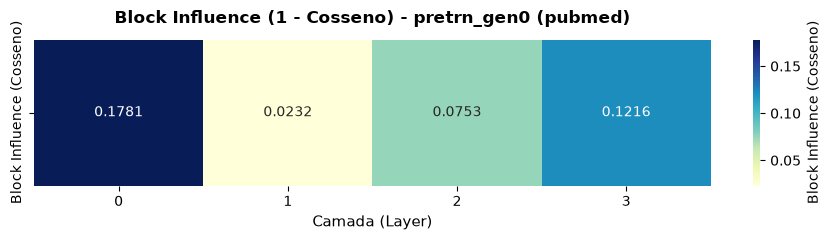

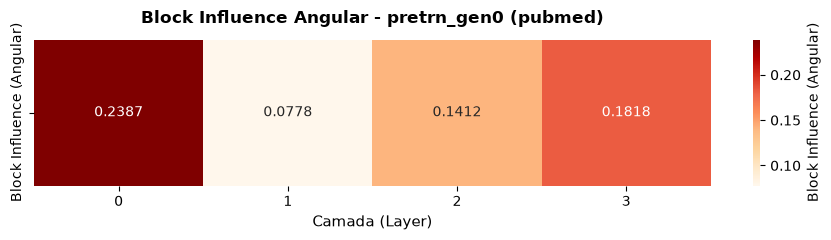

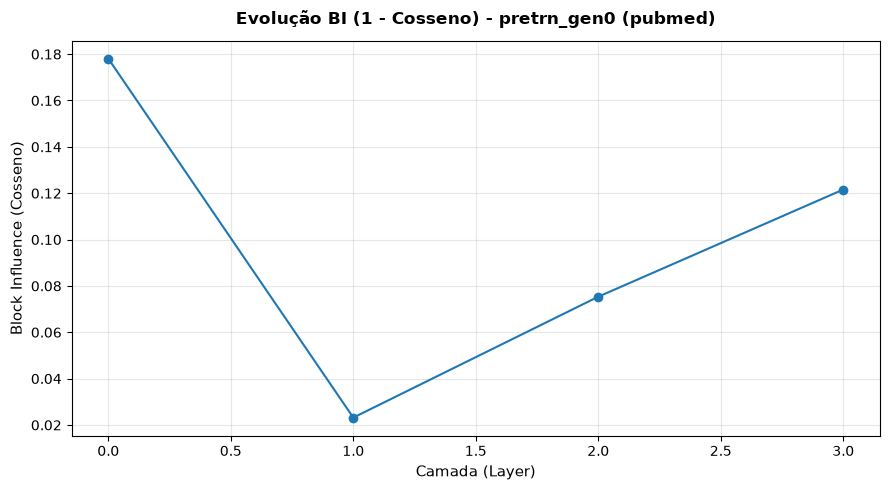

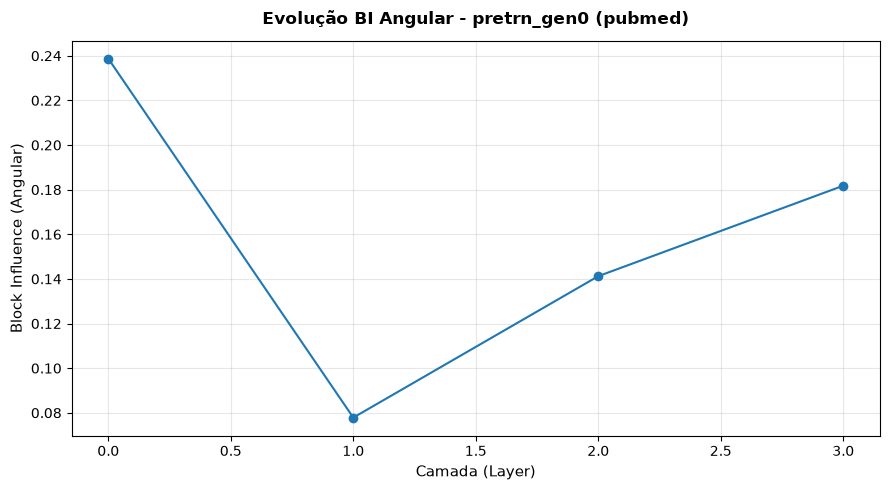


--------------------------------------------------------------------------------
PROCESSANDO: pretrn_gen0 | DATASET: cora
--------------------------------------------------------------------------------

BI Cosseno:


,Layer,Block Influence (Cosseno)
0,0,0.083497
1,1,0.017202
2,2,0.045190
3,3,0.074183



BI Angular:


,Layer,Block Influence (Angular)
0,0,0.129087
1,1,0.058317
2,2,0.092818
3,3,0.120705


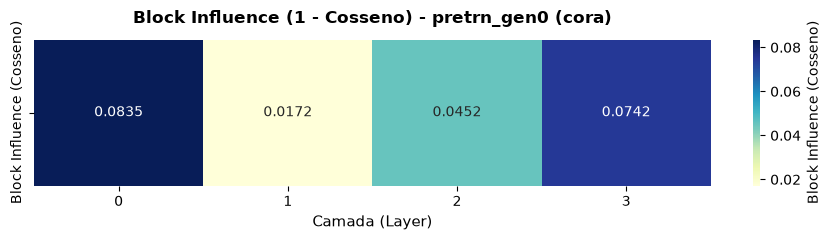

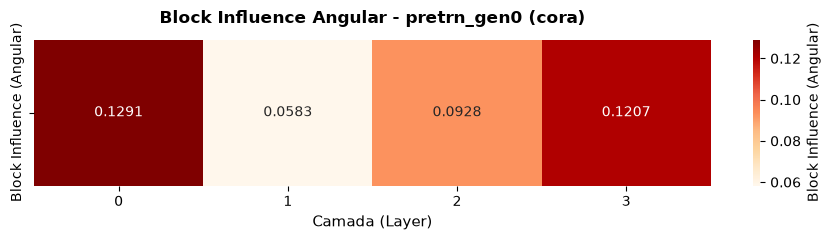

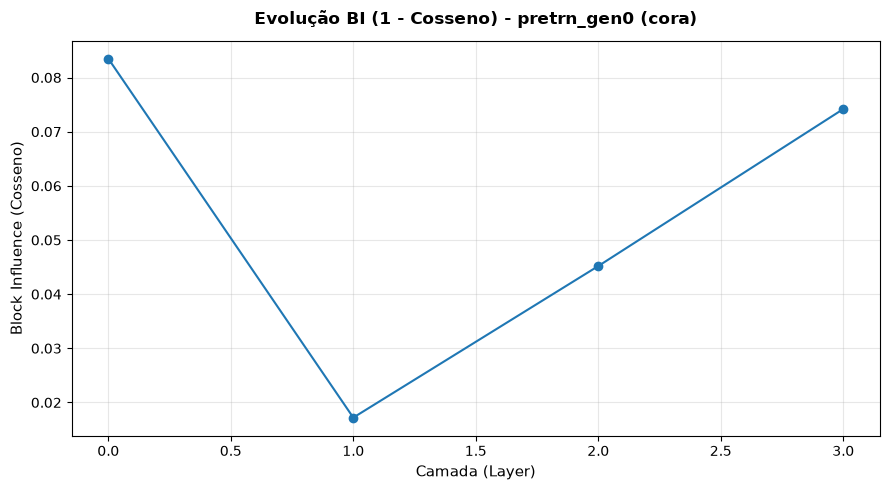

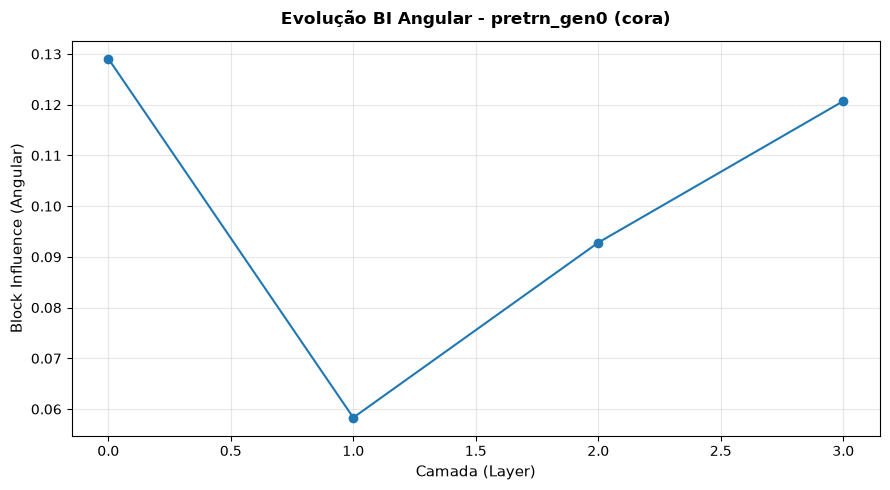


MODELO: pretrn_gen1
Loading model from: c:\Mestrado\Graph_Pruning\OpenGraph\Models\pretrn_gen1.mod
Loading history from: c:\Mestrado\Graph_Pruning\OpenGraph\History\pretrn_gen1.his
2026-09-10 14:58:01.754162: Model Loaded
Modelo pretrn_gen1 carregado
Layers: 4

--------------------------------------------------------------------------------
PROCESSANDO: pretrn_gen1 | DATASET: pubmed
--------------------------------------------------------------------------------

BI Cosseno:


,Layer,Block Influence (Cosseno)
0,0,0.203841
1,1,0.027749
2,2,0.014596
3,3,0.009353



BI Angular:


,Layer,Block Influence (Angular)
0,0,0.212888
1,1,0.077191
2,2,0.054498
3,3,0.043911


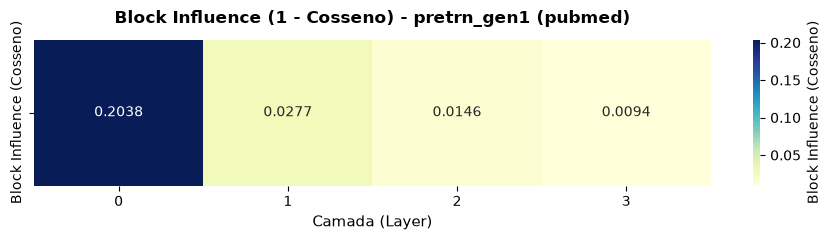

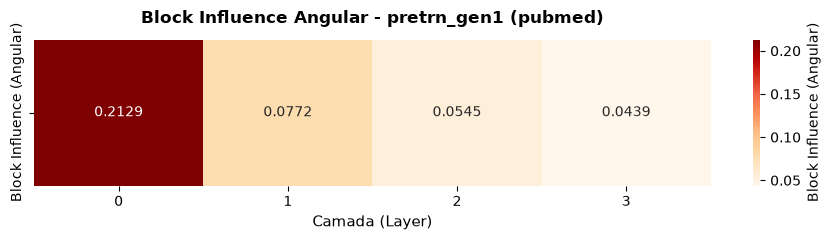

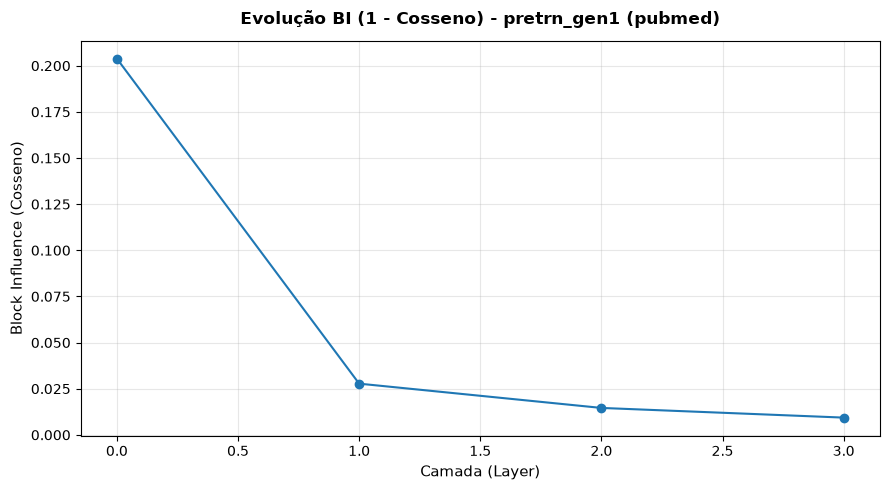

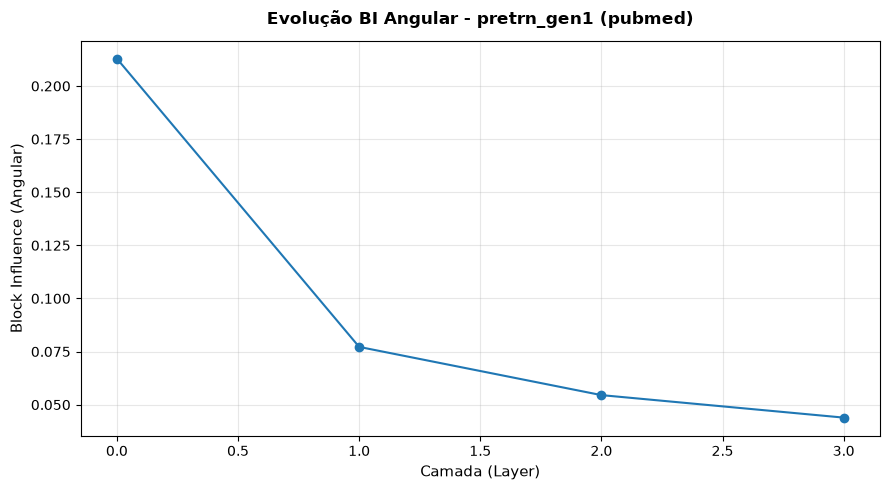


--------------------------------------------------------------------------------
PROCESSANDO: pretrn_gen1 | DATASET: cora
--------------------------------------------------------------------------------

BI Cosseno:


,Layer,Block Influence (Cosseno)
0,0,0.049123
1,1,0.014492
2,2,0.008860
3,3,0.005420



BI Angular:


,Layer,Block Influence (Angular)
0,0,0.104785
1,1,0.053323
2,2,0.042016
3,3,0.033705


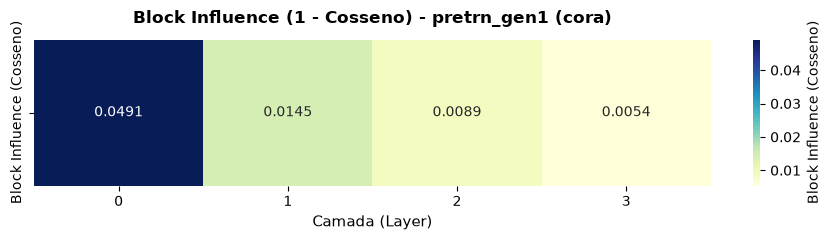

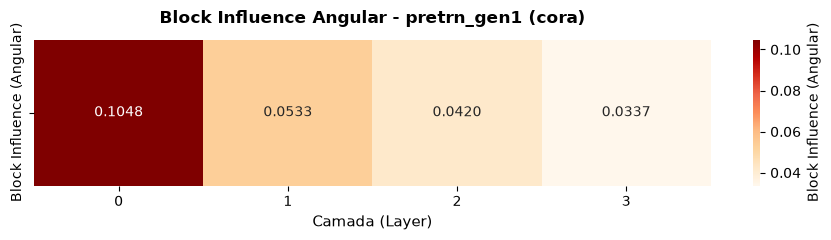

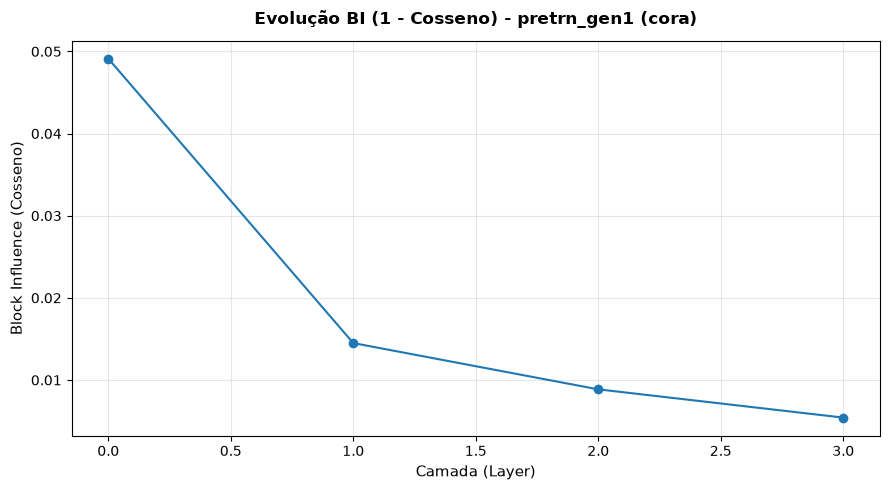

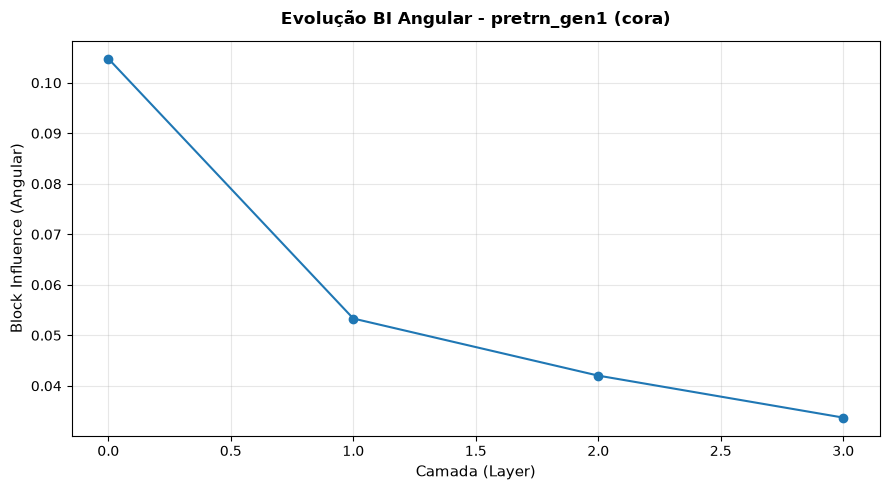


MODELO: pretrn_gen2
Loading model from: c:\Mestrado\Graph_Pruning\OpenGraph\Models\pretrn_gen2.mod
Loading history from: c:\Mestrado\Graph_Pruning\OpenGraph\History\pretrn_gen2.his
2026-09-10 14:58:04.647276: Model Loaded
Modelo pretrn_gen2 carregado
Layers: 4

--------------------------------------------------------------------------------
PROCESSANDO: pretrn_gen2 | DATASET: pubmed
--------------------------------------------------------------------------------

BI Cosseno:


,Layer,Block Influence (Cosseno)
0,0,0.248164
1,1,0.037764
2,2,0.019341
3,3,0.011345



BI Angular:


,Layer,Block Influence (Angular)
0,0,0.231454
1,1,0.087439
2,2,0.064412
3,3,0.048800


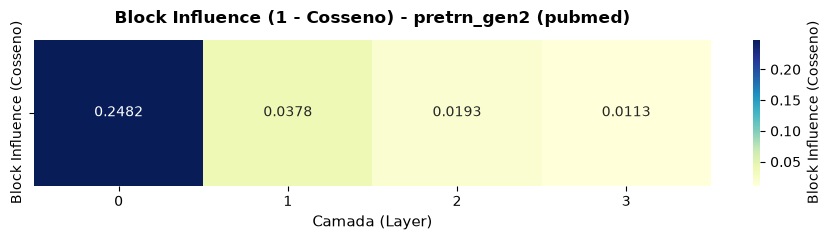

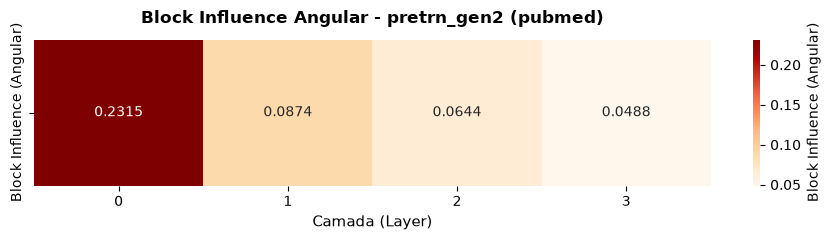

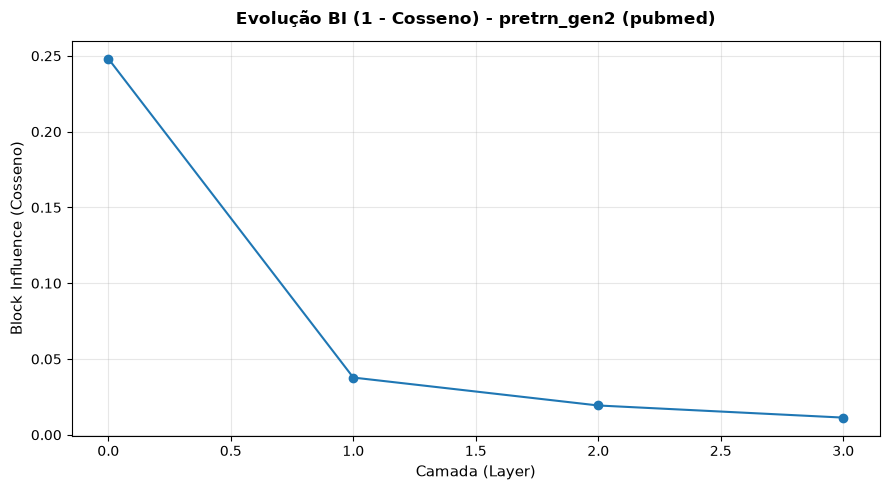

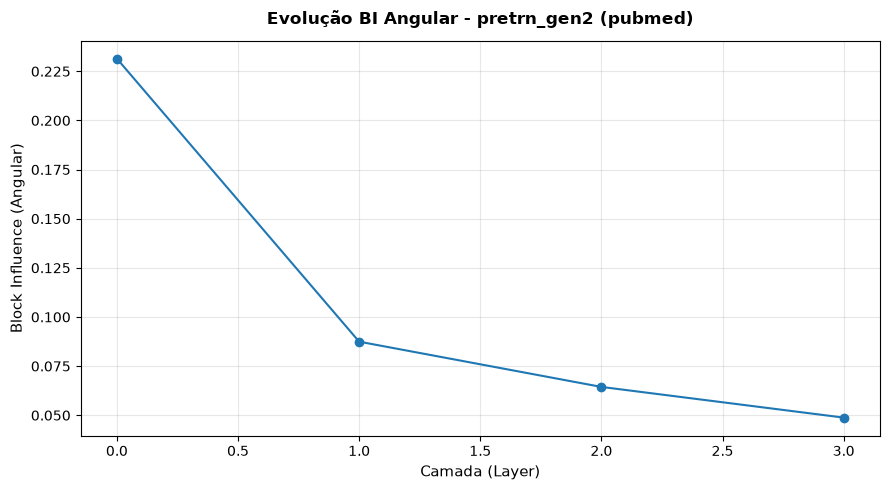


--------------------------------------------------------------------------------
PROCESSANDO: pretrn_gen2 | DATASET: cora
--------------------------------------------------------------------------------

BI Cosseno:


,Layer,Block Influence (Cosseno)
0,0,0.065834
1,1,0.023288
2,2,0.013595
3,3,0.008296



BI Angular:


,Layer,Block Influence (Angular)
0,0,0.111844
1,1,0.066115
2,2,0.051404
3,3,0.041355


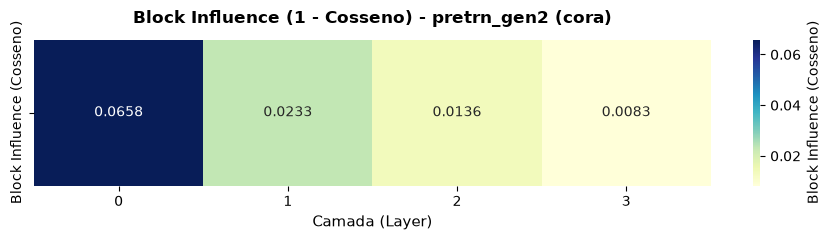

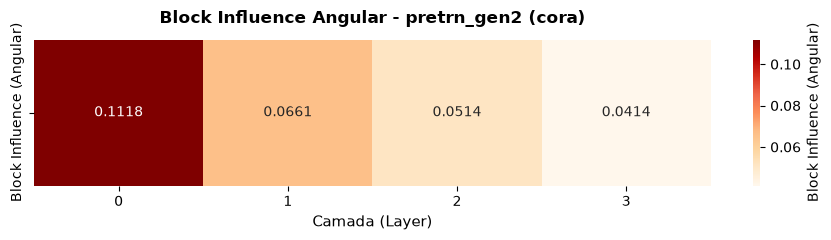

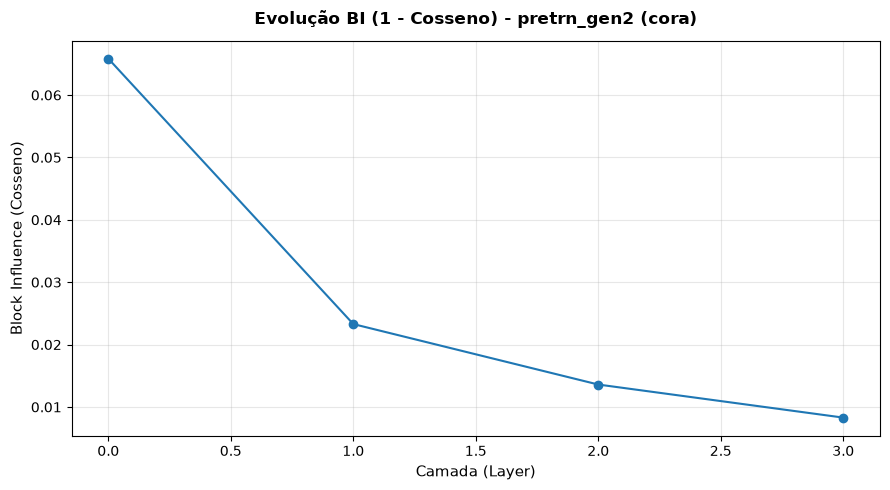

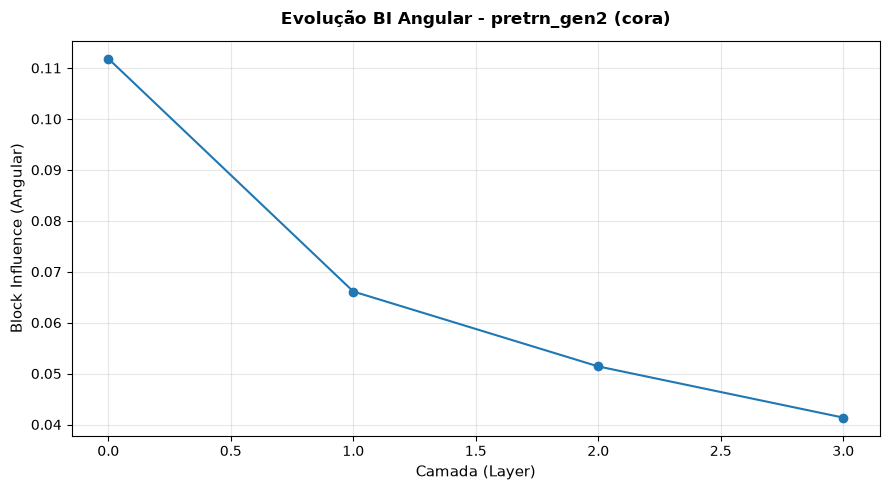


ANÁLISE DE BLOCK INFLUENCE FINALIZADA


In [17]:
# ==============================================================================
# LOOP PRINCIPAL - OPENGRAPH
# ==============================================================================

cos_col = "Block Influence (Cosseno)"
ang_col = "Block Influence (Angular)"

all_results = {}

print("Carregando modelos pré-treinados...")

for model_name in [
    "pretrn_gen0",
    "pretrn_gen1",
    "pretrn_gen2"
]:

    print("\n" + "=" * 80)
    print(f"MODELO: {model_name}")
    print("=" * 80)

    # Carrega o checkpoint
    args.load_model = model_name
    exp.load_model()

    print(f"Modelo {model_name} carregado")
    print(
        f"Layers: "
        f"{len(exp.model.graphTransformer.gt_layers)}"
    )

    all_results[model_name] = {}

    # --------------------------------------------------------------------------
    # DATASETS
    # --------------------------------------------------------------------------

    for handler in exp.multi_handler.tst_handlers:

        dset_tag = handler.data_name.lower()

        if dset_tag not in DATASETS_TO_RUN:
            continue

        print("\n" + "-" * 80)
        print(
            f"PROCESSANDO: {model_name} | "
            f"DATASET: {dset_tag}"
        )
        print("-" * 80)

        # ----------------------------------------------------------------------
        # BI COSSENO
        # ----------------------------------------------------------------------

        df_bi_cos = evaluate_opengraph_block_influence(
            exp,
            handler,
            angular=False
        )

        # ----------------------------------------------------------------------
        # BI ANGULAR
        # ----------------------------------------------------------------------

        df_bi_ang = evaluate_opengraph_block_influence(
            exp,
            handler,
            angular=True
        )

        # Guarda os resultados
        all_results[model_name][dset_tag] = {
            "cos": df_bi_cos,
            "ang": df_bi_ang
        }

        # ----------------------------------------------------------------------
        # RESULTADOS
        # ----------------------------------------------------------------------

        print("\nBI Cosseno:")
        display(df_bi_cos)

        print("\nBI Angular:")
        display(df_bi_ang)

        # ----------------------------------------------------------------------
        # SALVAR CSV - COSSENO
        # ----------------------------------------------------------------------

        for d in ALL_COS_DIRS:

            df_bi_cos.to_csv(
                os.path.join(
                    d,
                    f"block_influence_cosseno_"
                    f"{model_name}_"
                    f"{dset_tag}_raw.csv"
                ),
                index=False
            )

        # ----------------------------------------------------------------------
        # SALVAR CSV - ANGULAR
        # ----------------------------------------------------------------------

        for d in ALL_ANG_DIRS:

            df_bi_ang.to_csv(
                os.path.join(
                    d,
                    f"block_influence_angular_"
                    f"{model_name}_"
                    f"{dset_tag}_raw.csv"
                ),
                index=False
            )

        # ----------------------------------------------------------------------
        # HEATMAP - COSSENO
        # ----------------------------------------------------------------------

        plot_bi_heatmap(
            df_bi_cos,
            cos_col,
            f"Block Influence (1 - Cosseno) - "
            f"{model_name} ({dset_tag})",
            cmap="YlGnBu",
            save_paths=[
                os.path.join(
                    d,
                    f"heatmap_cosseno_"
                    f"{model_name}_"
                    f"{dset_tag}.png"
                )
                for d in ALL_COS_DIRS
            ]
        )

        # ----------------------------------------------------------------------
        # HEATMAP - ANGULAR
        # ----------------------------------------------------------------------

        plot_bi_heatmap(
            df_bi_ang,
            ang_col,
            f"Block Influence Angular - "
            f"{model_name} ({dset_tag})",
            cmap="OrRd",
            save_paths=[
                os.path.join(
                    d,
                    f"heatmap_angular_"
                    f"{model_name}_"
                    f"{dset_tag}.png"
                )
                for d in ALL_ANG_DIRS
            ]
        )

        # ----------------------------------------------------------------------
        # CURVA - COSSENO
        # ----------------------------------------------------------------------

        plot_bi_curves(
            df_bi_cos,
            cos_col,
            f"Evolução BI (1 - Cosseno) - "
            f"{model_name} ({dset_tag})",
            save_paths=[
                os.path.join(
                    d,
                    f"curves_cosseno_"
                    f"{model_name}_"
                    f"{dset_tag}.png"
                )
                for d in ALL_COS_DIRS
            ]
        )

        # ----------------------------------------------------------------------
        # CURVA - ANGULAR
        # ----------------------------------------------------------------------

        plot_bi_curves(
            df_bi_ang,
            ang_col,
            f"Evolução BI Angular - "
            f"{model_name} ({dset_tag})",
            save_paths=[
                os.path.join(
                    d,
                    f"curves_angular_"
                    f"{model_name}_"
                    f"{dset_tag}.png"
                )
                for d in ALL_ANG_DIRS
            ]
        )

print("\n" + "=" * 80)
print("ANÁLISE DE BLOCK INFLUENCE FINALIZADA")
print("=" * 80)

## 3. Análise Acadêmica Consolidada Cross-Dataset

Nesta seção, consolidamos os resultados entre **todos os datasets avaliados** (`cora`, `pubmed`, `synthetic`) para comprovar a **invariância de domínio e robustez estatística** da decisão de poda estruturada.

In [20]:
master_rows = []

MODELS_TO_RUN = [
    "pretrn_gen0",
    "pretrn_gen1",
    "pretrn_gen2"
]

DATASETS_TO_RUN = [
    "cora",
    "pubmed"
]

for dset in DATASETS_TO_RUN:

    dset_tag = dset.lower()

    for model_name in MODELS_TO_RUN:

        df_cos = all_results[model_name][dset_tag]["cos"]
        df_ang = all_results[model_name][dset_tag]["ang"]

        for l in range(4):

            row_cos = df_cos[
                df_cos["Layer"] == l
            ].iloc[0]

            row_ang = df_ang[
                df_ang["Layer"] == l
            ].iloc[0]

            master_rows.append({

                "Dataset": dset_tag,

                "Modelo": model_name,

                "Camada": l,

                "BI (Cosseno)": row_cos[
                    "Block Influence (Cosseno)"
                ],

                "BI (Angular)": row_ang[
                    "Block Influence (Angular)"
                ],

                "Ângulo (Graus)": (
                    row_ang[
                        "Block Influence (Angular)"
                    ] * 180.0
                )
            })


df_master = pd.DataFrame(master_rows)


# ==============================================================================
# SALVAR
# ==============================================================================

for d in ALL_COMP_DIRS:

    df_master.to_csv(
        os.path.join(
            d,
            "master_academic_comparison_all_datasets.csv"
        ),
        index=False
    )


# ==============================================================================
# EXIBIR
# ==============================================================================

print(
    "=== TABELA MASTER CONSOLIDADA - OPENGRAPH ==="
)

display(df_master)

=== TABELA MASTER CONSOLIDADA - OPENGRAPH ===


,Dataset,Modelo,Camada,BI (Cosseno),BI (Angular),Ângulo (Graus)
0,cora,pretrn_gen0,0,0.083497,0.129087,23.235714
1,cora,pretrn_gen0,1,0.017202,0.058317,10.497027
2,cora,pretrn_gen0,2,0.045190,0.092818,16.707249
3,cora,pretrn_gen0,3,0.074183,0.120705,21.726923
4,cora,pretrn_gen1,0,0.049123,0.104785,18.861296
5,cora,pretrn_gen1,1,0.014492,0.053323,9.598068
6,cora,pretrn_gen1,2,0.008860,0.042016,7.562955
7,cora,pretrn_gen1,3,0.005420,0.033705,6.066819
8,cora,pretrn_gen2,0,0.065834,0.111844,20.131996
9,cora,pretrn_gen2,1,0.023288,0.066115,11.900731


=== TABELA MASTER CONSOLIDADA ACADÊMICA (CROSS-DATASET) ===


,Dataset,Camada,M1 BI (Cosseno),M1 BI (Angular),M1 Ângulo (Graus),M1 Rank Poda,M2 BI (Cosseno),M2 BI (Angular),M2 Ângulo (Graus),M2 Rank Poda
0,cora,0,0.078180,0.124939,22.489013,6,0.105714,0.144716,26.048851,7
1,cora,1,0.077137,0.124163,22.349364,5,0.092817,0.136043,24.487682,5
2,cora,2,0.153052,0.174479,31.406216,8,0.160658,0.180292,32.452647,8
3,cora,3,0.095493,0.135207,24.337212,7,0.094121,0.136331,24.539632,6
4,cora,4,0.022180,0.063523,11.434160,4,0.023756,0.066140,11.905271,3
5,cora,5,0.007935,0.038387,6.909577,2,0.009516,0.041367,7.446008,2
6,cora,6,0.005545,0.032924,5.926231,1,0.008061,0.039739,7.152946,1
7,cora,7,0.019596,0.061044,10.987886,3,0.029733,0.076031,13.685652,4
8,pubmed,0,0.075414,0.122844,22.111910,5,0.110679,0.147642,26.575609,7
9,pubmed,1,0.076259,0.123226,22.180753,6,0.095477,0.137909,24.823586,6


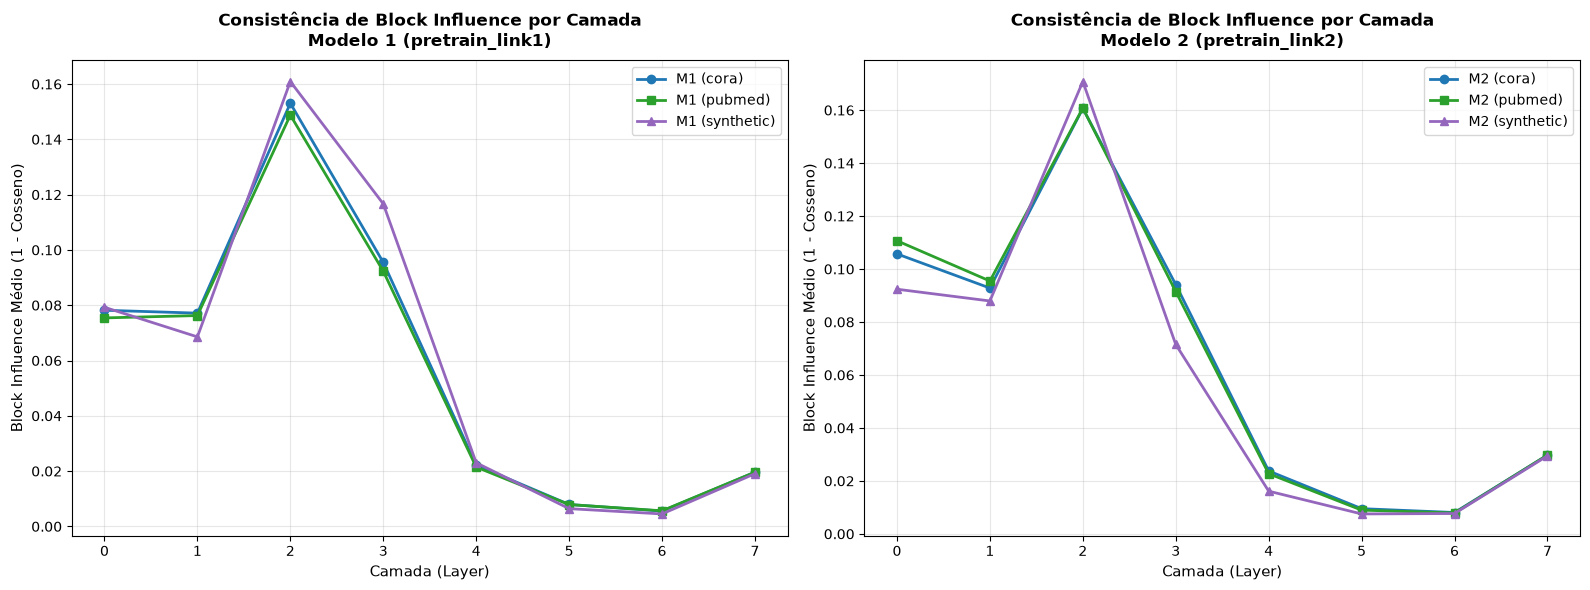

In [45]:
# Tabela Master Consolidada: Modelo 1 e Modelo 2 em todos os datasets
master_rows = []

for dset in DATASETS_TO_RUN:
    dset_tag = dset.lower()
    m1_comp = all_comp_metrics[dset_tag]["m1"].sort_values("Camada")
    m2_comp = all_comp_metrics[dset_tag]["m2"].sort_values("Camada")
    
    for l in range(8):
        row_m1 = m1_comp[m1_comp["Camada"] == l].iloc[0]
        row_m2 = m2_comp[m2_comp["Camada"] == l].iloc[0]
        
        master_rows.append({
            "Dataset": dset_tag,
            "Camada": l,
            "M1 BI (Cosseno)": row_m1["BI Medio (Cosseno)"],
            "M1 BI (Angular)": row_m1["BI Medio (Angular)"],
            "M1 Ângulo (Graus)": row_m1["Angulo Medio (Graus)"],
            "M1 Rank Poda": row_m1["Ranking Cosseno"],
            "M2 BI (Cosseno)": row_m2["BI Medio (Cosseno)"],
            "M2 BI (Angular)": row_m2["BI Medio (Angular)"],
            "M2 Ângulo (Graus)": row_m2["Angulo Medio (Graus)"],
            "M2 Rank Poda": row_m2["Ranking Cosseno"],
        })

df_master = pd.DataFrame(master_rows)
for d in ALL_COMP_DIRS:
    df_master.to_csv(os.path.join(d, "master_academic_comparison_all_datasets.csv"), index=False)

print("=== TABELA MASTER CONSOLIDADA ACADÊMICA (CROSS-DATASET) ===")
display(df_master.head(16))

# Gráfico de Consistência Cross-Dataset (Evolução do BI ao longo das Camadas para cada Dataset)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

colors = {"cora": "tab:blue", "pubmed": "tab:green", "synthetic": "tab:purple"}
markers = {"cora": "o", "pubmed": "s", "synthetic": "^"}

for dset in DATASETS_TO_RUN:
    dset_tag = dset.lower()
    sub_df = df_master[df_master["Dataset"] == dset_tag]
    c = colors.get(dset_tag, "black")
    m = markers.get(dset_tag, "o")
    
    ax1.plot(sub_df["Camada"], sub_df["M1 BI (Cosseno)"], marker=m, color=c, linewidth=2, label=f"M1 ({dset_tag})")
    ax2.plot(sub_df["Camada"], sub_df["M2 BI (Cosseno)"], marker=m, color=c, linewidth=2, label=f"M2 ({dset_tag})")

ax1.set_title("Consistência de Block Influence por Camada\nModelo 1 (pretrain_link1)", fontsize=12, fontweight="bold", pad=10)
ax1.set_xlabel("Camada (Layer)", fontsize=11)
ax1.set_ylabel("Block Influence Médio (1 - Cosseno)", fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=10)

ax2.set_title("Consistência de Block Influence por Camada\nModelo 2 (pretrain_link2)", fontsize=12, fontweight="bold", pad=10)
ax2.set_xlabel("Camada (Layer)", fontsize=11)
ax2.set_ylabel("Block Influence Médio (1 - Cosseno)", fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=10)

plt.tight_layout()
for d in ALL_COMP_DIRS:
    plt.savefig(os.path.join(d, "cross_dataset_consistency_comparison.png"), dpi=300)
plt.show()